# 5주차 1번 과제

1. ResNet으로 이미지 분류
2. VGG16 전이 학습
3. ResNet vs VGG16 성능 비교
4. 가상 데이터셋 + GridSearch / RandomSearch

In [1]:
import copy
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights, VGG16_Weights

DATA_DIR = Path("data/cifar10")
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-3
NUM_CLASSES = 10

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

print("device:", device)

device: mps


## 공통: CIFAR-10 데이터셋 다운로드 및 DataLoader

In [2]:
# ImageNet 사전학습 가중치에 맞는 전처리
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_train = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_transform)

# train 45000 / val 5000 분할
val_size = 5000
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = full_train.classes
print("train:", len(train_dataset), "val:", len(val_dataset), "test:", len(test_dataset))
print("classes:", class_names)

train: 45000 val: 5000 test: 10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
def build_model(model_name, num_classes=NUM_CLASSES):
    if model_name == "resnet18":
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "vgg16":
        model = models.vgg16(weights=VGG16_Weights.DEFAULT)
        for param in model.features.parameters():
            param.requires_grad = False
        model.classifier[6] = nn.Linear(4096, num_classes)
    else:
        raise ValueError(f"unknown model: {model_name}")
    return model.to(device)


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"epoch {epoch + 1}/{epochs} | train acc {train_acc:.4f} | val acc {val_acc:.4f}")

    model.load_state_dict(best_state)
    history["train_time_sec"] = time.time() - start
    return model, history


def evaluate(model, data_loader, criterion=None):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if criterion is not None:
                running_loss += criterion(outputs, labels).item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / total if criterion is not None else 0.0
    acc = correct / total
    return loss, acc

## 1. ResNet 모델을 불러와 CIFAR-10 분류

In [4]:
resnet = build_model("resnet18")
resnet, resnet_history = train_model(resnet, train_loader, val_loader)

resnet_test_loss, resnet_test_acc = evaluate(resnet, test_loader, nn.CrossEntropyLoss())
print(f"ResNet18 test accuracy: {resnet_test_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/kimtaekyu/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 29.0MB/s]


epoch 1/5 | train acc 0.7242 | val acc 0.7806
epoch 2/5 | train acc 0.7852 | val acc 0.8000
epoch 3/5 | train acc 0.7937 | val acc 0.7950
epoch 4/5 | train acc 0.7979 | val acc 0.8046
epoch 5/5 | train acc 0.8016 | val acc 0.8076
ResNet18 test accuracy: 0.8050


## 2. 사전 훈련된 VGG16으로 전이 학습

In [5]:
vgg16 = build_model("vgg16")
vgg16, vgg_history = train_model(vgg16, train_loader, val_loader)

vgg_test_loss, vgg_test_acc = evaluate(vgg16, test_loader, nn.CrossEntropyLoss())
print(f"VGG16 test accuracy: {vgg_test_acc:.4f}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/kimtaekyu/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:22<00:00, 24.9MB/s] 


epoch 1/5 | train acc 0.7754 | val acc 0.8464
epoch 2/5 | train acc 0.8288 | val acc 0.8126
epoch 3/5 | train acc 0.8522 | val acc 0.8680
epoch 4/5 | train acc 0.8648 | val acc 0.8692
epoch 5/5 | train acc 0.8783 | val acc 0.8734
VGG16 test accuracy: 0.8727


## 3. ResNet vs VGG16 성능 비교

ResNet18 | val acc: 0.8076 | test acc: 0.8050 | time: 344.6s
VGG16 | val acc: 0.8734 | test acc: 0.8727 | time: 1365.6s


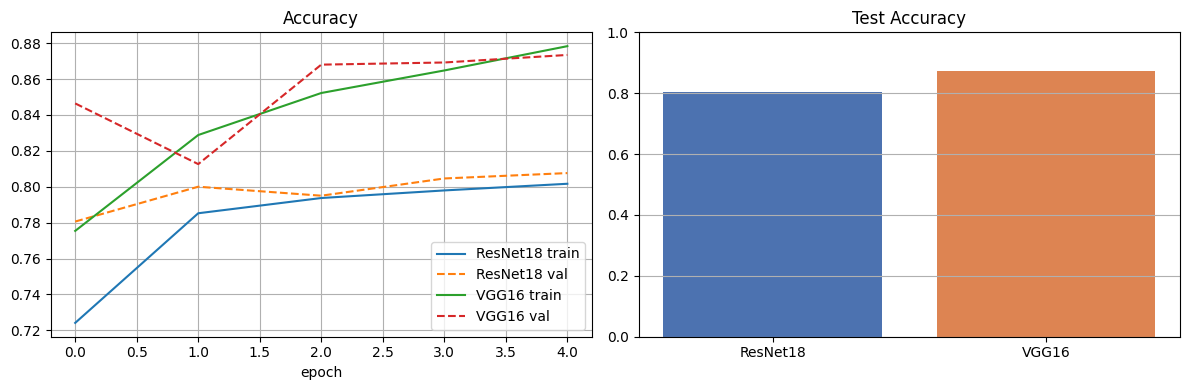

In [6]:
comparison = {
    "model": ["ResNet18", "VGG16"],
    "val_acc": [resnet_history["val_acc"][-1], vgg_history["val_acc"][-1]],
    "test_acc": [resnet_test_acc, vgg_test_acc],
    "train_time_sec": [resnet_history["train_time_sec"], vgg_history["train_time_sec"]],
}

for i in range(2):
    print(
        f"{comparison['model'][i]} | "
        f"val acc: {comparison['val_acc'][i]:.4f} | "
        f"test acc: {comparison['test_acc'][i]:.4f} | "
        f"time: {comparison['train_time_sec'][i]:.1f}s"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for history, label in [(resnet_history, "ResNet18"), (vgg_history, "VGG16")]:
    axes[0].plot(history["train_acc"], label=f"{label} train")
    axes[0].plot(history["val_acc"], linestyle="--", label=f"{label} val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].bar(comparison["model"], comparison["test_acc"], color=["#4C72B0", "#DD8452"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Test Accuracy")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

## 4. 가상 데이터셋 생성 + GridSearch / RandomSearch

In [7]:
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=3,
    class_sep=1.2,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42)),
])

param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
}

param_dist = {
    "clf__n_estimators": [50, 100, 150, 200, 250],
    "clf__max_depth": [None, 5, 10, 15, 20, 30],
    "clf__min_samples_split": [2, 3, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)

grid_pred = grid_search.predict(X_test)
random_pred = random_search.predict(X_test)

print("GridSearch best params:", grid_search.best_params_)
print("GridSearch CV score:", grid_search.best_score_)
print("GridSearch test acc:", accuracy_score(y_test, grid_pred))
print()
print("RandomSearch best params:", random_search.best_params_)
print("RandomSearch CV score:", random_search.best_score_)
print("RandomSearch test acc:", accuracy_score(y_test, random_pred))
print()
print("[GridSearch report]")
print(classification_report(y_test, grid_pred))
print("[RandomSearch report]")
print(classification_report(y_test, random_pred))

GridSearch best params: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
GridSearch CV score: 0.8518842535011348
GridSearch test acc: 0.855

RandomSearch best params: {'clf__n_estimators': 150, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 30}
RandomSearch CV score: 0.8506369851943982
RandomSearch test acc: 0.86

[GridSearch report]
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       132
           1       0.89      0.83      0.86       134
           2       0.88      0.86      0.87       134

    accuracy                           0.85       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.85      0.86       400

[RandomSearch report]
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       132
           1       0.90      0.83      0.86       134
           2       0.88      0.87      0.